# Imóveis da Califórnia - Regressão Linear

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

### Carregamento dos dados

In [2]:
dados = fetch_california_housing()

df = pd.DataFrame(dados.data, columns=dados.feature_names)
df["Alvo"] = dados.target


### Preparar os dados e Treinar o Modelo

array([0.71912284, 1.76401657, 2.70965883, ..., 4.46877017, 1.18751119,
       2.00940251], shape=(4128,))

'MSE: 55589.159870'

'R2: 0.575788'

,Dado Preditivo,Coeficiente
0,MedInc,0.448675
1,HouseAge,0.009724
2,AveRooms,-0.123323
3,AveBedrms,0.783145
4,Population,-0.000002
5,AveOccup,-0.003526
6,Latitude,-0.419792
7,Longitude,-0.433708


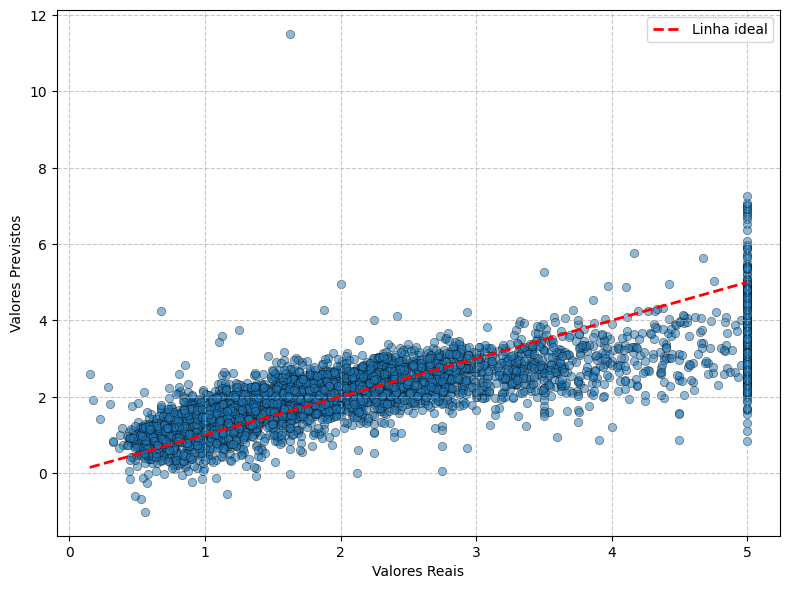

In [5]:
dados_preditivos = df[dados.feature_names]

alvos = df["Alvo"]

dados_preditivos_treino, dados_preditivos_teste, alvos_treino, alvos_teste = train_test_split(dados_preditivos, alvos, test_size=0.2, random_state=42)

linear = LinearRegression()
linear.fit(dados_preditivos_treino, alvos_treino)

alvos_previsao = linear.predict(dados_preditivos_teste)

display(alvos_previsao)

df_previsao = dados_preditivos_teste
df_previsao["Alvo Previsto"] = alvos_previsao * 100000
df_previsao["Alvo Gabarito"] = alvos_teste *100000

df_previsao["Alvo Previsto"] = df_previsao["Alvo Previsto"].round(2)
df_previsao["Alvo Gabarito"] = df_previsao["Alvo Gabarito"].round(2)

mse = mean_squared_error(alvos_teste, alvos_previsao)
r2 = r2_score(alvos_teste, alvos_previsao)


display(f'MSE: {mse*100000:4f}')
display(f"R2: {r2:4f}")

coeficientes = pd.DataFrame({
    "Dado Preditivo": dados.feature_names,
    "Coeficiente": linear.coef_
})

display(coeficientes)    

plt.figure(figsize=(8, 6))

plt.scatter(alvos_teste, alvos_previsao, alpha=0.5, edgecolors='k', linewidths=0.5)
plt.plot([alvos_teste.min(), alvos_teste.max()], [alvos_teste.min(), alvos_teste.max()], 'r--', lw=2, label="Linha ideal")

plt.xlabel("Valores Reais")
plt.ylabel("Valores Previstos")

plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()



